# Кластеризация типов сигналов

Команда: STEAM in DREAM

состав: Майоров Александр, Двояшов Владимир, Комиссаров Владимир, Хабарова София, Александрова Ольга

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 5)

Число сигналов: 3000
Отсчётов в одном сигнале: 500


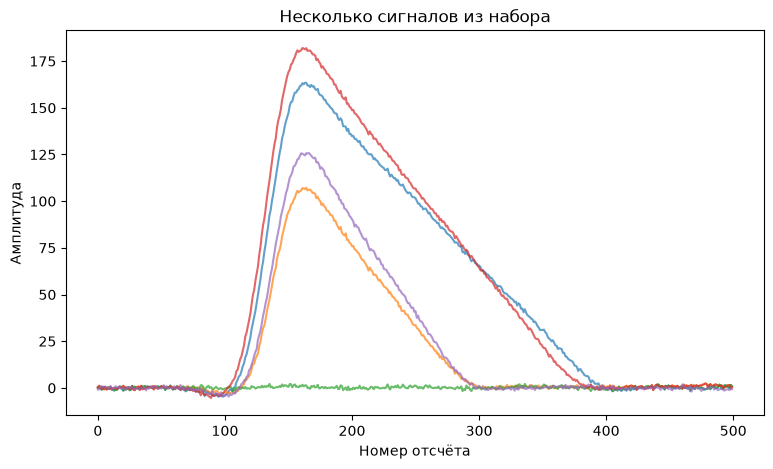

In [2]:
data = pd.read_csv('data_4W_sem.csv', header=None)
signals = data.to_numpy()

baseline = signals[:, :50].mean(axis=1)
signals = signals - baseline[:, None]

print('Число сигналов:', len(signals))
print('Отсчётов в одном сигнале:', signals.shape[1])

for signal in signals[:5]:
    plt.plot(signal, alpha=0.7)

plt.title('Несколько сигналов из набора')
plt.xlabel('Номер отсчёта')
plt.ylabel('Амплитуда')
plt.show()

Для каждого сигнала найдём амплитуду, ширину на половине высоты и время, за которое сигнал после максимума падает до 10% от максимума.

In [3]:
def signal_features(signal):
    peak = np.argmax(signal)
    amplitude = signal[peak]

    half = amplitude / 2
    left = np.where(signal[:peak] < half)[0]
    right = np.where(signal[peak:] < half)[0]

    if len(left) == 0:
        left = 0
    else:
        left = left[-1]

    if len(right) == 0:
        right = len(signal) - 1
    else:
        right = peak + right[0]

    low = np.where(signal[peak:] < 0.1 * amplitude)[0]
    if len(low) == 0:
        fall_time = len(signal) - peak
    else:
        fall_time = low[0]

    return amplitude, right - left, fall_time

rows = [signal_features(signal) for signal in signals]
features = pd.DataFrame(rows, columns=['amplitude', 'width', 'fall_time'])
features.head()

,amplitude,width,fall_time
0,163.398411,145,206
1,107.196758,91,114
2,2.112576,2,3
3,182.033856,138,194
4,125.797215,92,112


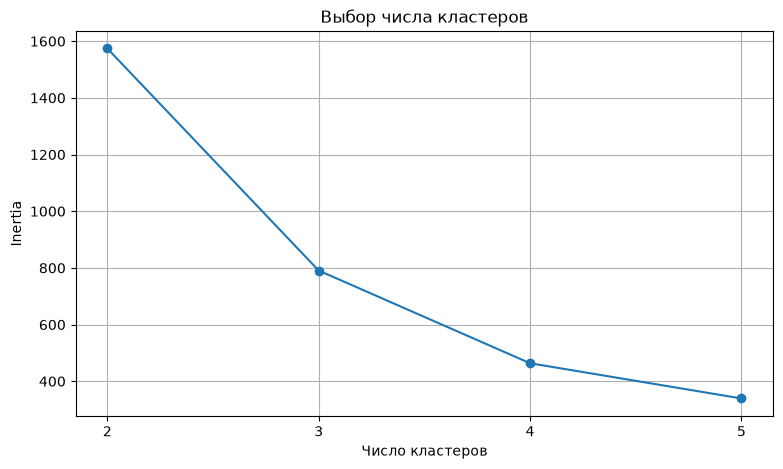

In [4]:
X = features[['width', 'fall_time']].to_numpy(dtype=float)
X = (X - X.mean(axis=0)) / X.std(axis=0)

def my_kmeans(points, k):
    rng = np.random.default_rng(1)
    centers = points[rng.choice(len(points), size=k, replace=False)]

    for step in range(100):
        distances = ((points[:, None] - centers) ** 2).sum(axis=2)
        labels = distances.argmin(axis=1)
        new_centers = centers.copy()

        for group in range(k):
            if np.any(labels == group):
                new_centers[group] = points[labels == group].mean(axis=0)

        if np.allclose(centers, new_centers):
            break
        centers = new_centers

    inertia = ((points - centers[labels]) ** 2).sum()
    return labels, centers, inertia

inertia = []
for k in range(2, 6):
    labels, centers, value = my_kmeans(X, k)
    inertia.append(value)

plt.plot(range(2, 6), inertia, 'o-')
plt.xticks(range(2, 6))
plt.xlabel('Число кластеров')
plt.ylabel('Inertia')
plt.title('Выбор числа кластеров')
plt.grid()
plt.show()

## Кластеризация

In [5]:
labels, centers, value = my_kmeans(X, 3)
features['cluster'] = labels

mean_fall_time = features.groupby('cluster')['fall_time'].mean().sort_values()
new_numbers = {cluster: i + 1 for i, cluster in enumerate(mean_fall_time.index)}
features['type'] = features['cluster'].map(new_numbers)

features.groupby('type')[['amplitude', 'width', 'fall_time']].mean().round(1)

,amplitude,width,fall_time
type,,,
1,30.8,41.1,42.1
2,100.7,85.1,105.1
3,162.4,128.8,178.3


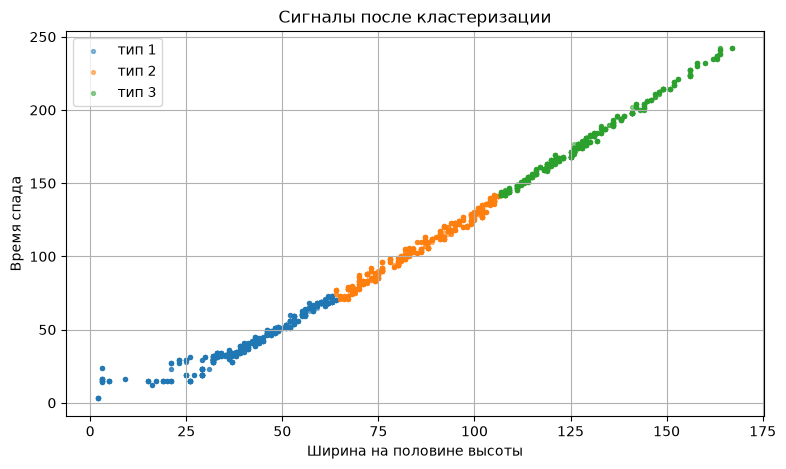

In [6]:
colors = ['tab:blue', 'tab:orange', 'tab:green']

for group, color in zip([1, 2, 3], colors):
    part = features[features['type'] == group]
    plt.scatter(part['width'], part['fall_time'], s=8, alpha=0.5,
                color=color, label=f'тип {group}')

plt.xlabel('Ширина на половине высоты')
plt.ylabel('Время спада')
plt.title('Сигналы после кластеризации')
plt.legend()
plt.grid()
plt.show()

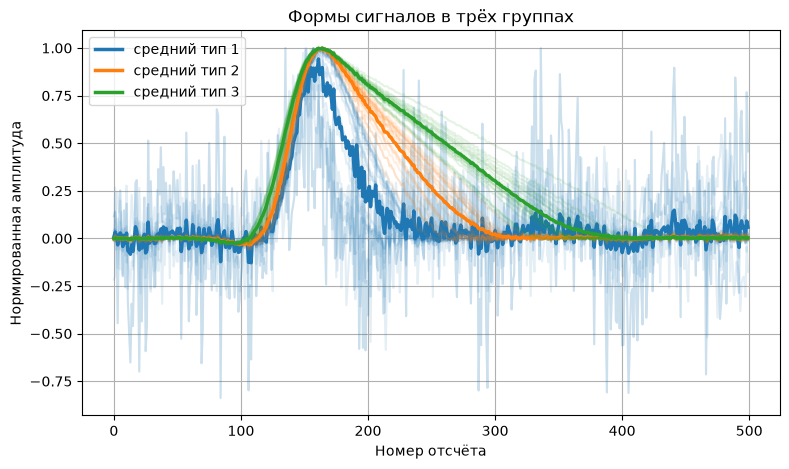

In [7]:
for group, color in zip([1, 2, 3], colors):
    indices = features.index[features['type'] == group][:20]

    for i in indices:
        normalized = signals[i] / features.loc[i, 'amplitude']
        plt.plot(normalized, color=color, alpha=0.12)

    average = np.mean([signals[i] / features.loc[i, 'amplitude'] for i in indices], axis=0)
    plt.plot(average, color=color, linewidth=2.5, label=f'средний тип {group}')

plt.xlabel('Номер отсчёта')
plt.ylabel('Нормированная амплитуда')
plt.title('Формы сигналов в трёх группах')
plt.legend()
plt.grid()
plt.show()

## Результат

In [8]:
print('Количество сигналов в группах:')
print(features['type'].value_counts().sort_index())

Количество сигналов в группах:
type
1    1047
2     993
3     960
Name: count, dtype: int64
Файл signal_analysis/signal_clusters.csv сохранён
